## PtyChee vSTEM and tcBF Demo

Running virtual STEM and tilt correction BF

Author: Zeyu Wang <br>
October 2025

In [1]:
import numpy as np
from PtyChee import run

4D-STEM data and parameters read in, this data uesd a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>.

In [2]:
file_read = 'data/'
file = 'MAPbI3_HT200_a13_ss0.3_31_F3sum.npy'
data_4D = np.load(file_read+file)
print(data_4D.shape)

Voltage = 200               #keV, accelerate votage
alpha = 0.013               #rad, semi convergence angle
scan_step = 0.3             #Å,   scan step size

defocus = -60               #Å,   defocus

(800, 800, 38, 38)


You can use PtyChee.finRotate to calculate the optimized scan rotate angle, <br>
see 'run_ptyChee_01_findRotate_and_iCoM_MAPbI3_F3sum.ipynb'

In [ ]:
scan_rotation_angle = -176   #degrees
scan_flip = False            #flip X axis or not

Run vSTEM <br>
In radius_list, set the inner and outer radii of the annular regions to be integrated, expressed as multiples of the aperture radius.


vSTEM
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

#################### Data Information ####################
data shape: (800, 800, 38, 38)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.6288480758667
BF center_Y: 18.581818181818182
BF center_X: 18.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

#################### vSTEM Parameters ####################
Radius Range List:
(0 - 1) Alpha
(0 - 0.5) Alpha
(0.5 - 1) Alpha
(1 - 2) Alpha
(1 - 3) Alpha
(2 - 3) Alpha

##################### vSTEM Process ######################
vSTEM progressing: 100%[**********->] 0.37iter/s (00:00:15<00:00:00)
vSTEM process finished in 15.956974506378174 s

################### Saving and Ploting ###################
vSTEM saving


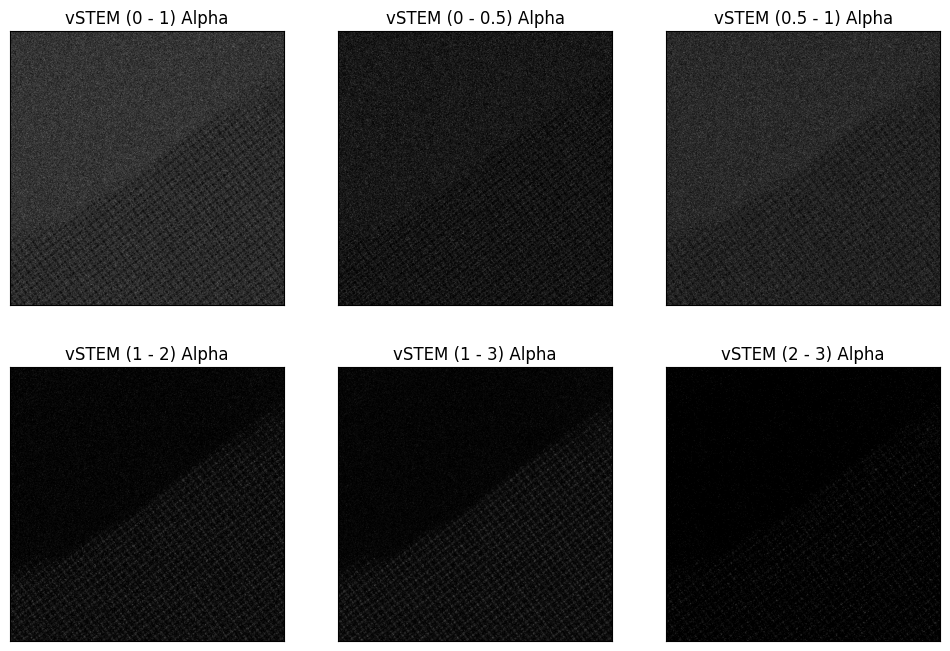

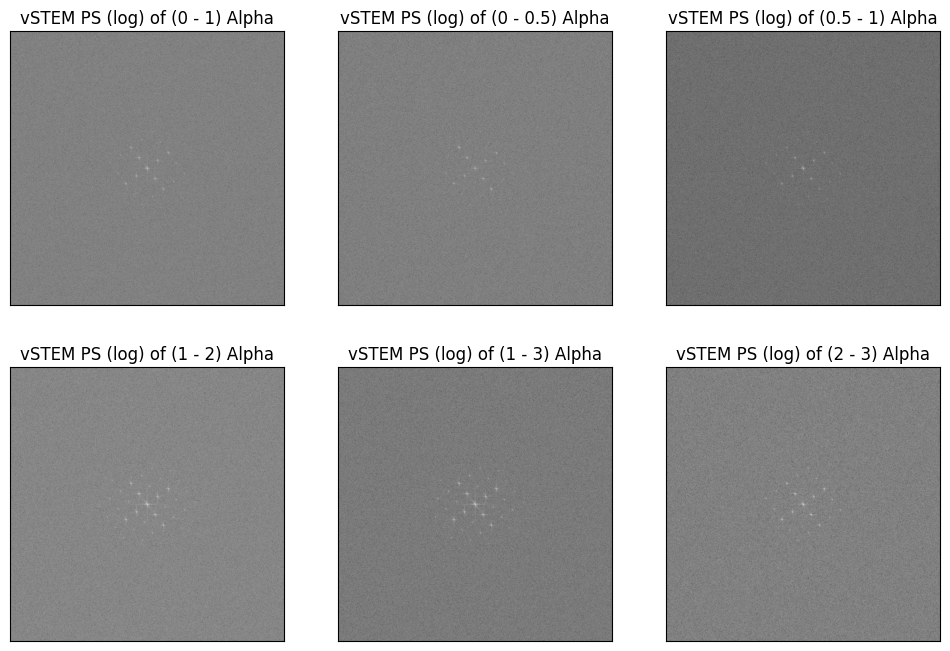

In [4]:
# vSTEM
run.run_vSTEM(file, data_4D,
        radius_list = [ [0, 1],
                        [0, 0.5],
                        [0.5, 1],
                        [1, 2],
                        [1, 3],
                        [2, 3],
                       ],              # list of inner of outer radiuses for the annular ROIs on CBED
        save_results = False,
)

Run tcBF, note that this tilt correction only consider the motion of the BF pattern caused by rotate, flip and defocus, not including the influence of other aberration


tcBF
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Alpha: 0.013 rad
scan step: 0.3 Å/pixel
defocus: -60 Å
scan rotation angle: -178 degrees
scan flip x: False

#################### Data Information ####################
data shape: (800, 800, 38, 38)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.6288480758667
BF center_Y: 18.581818181818182
BF center_X: 18.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

#################### tcBF Parameters #####################
vSTEM shift rotation angle: -178 degrees
vSTEM shift flip x: False
inner_radiuss: 0 Alpha
outer_radius: 1 Alpha

##################### tcBF Process #######################
tcBF progressing: 100%[**********->] 2.79iter/s (00:00:09<00:00:00))
tcBF process finished in 9.669720888137817 s

################### Saving and Ploting ###################
tcBF saving


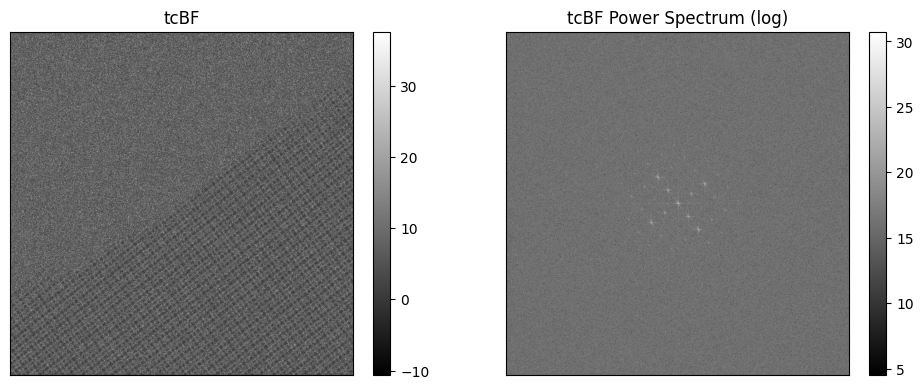

In [5]:
# tcBF
run.run_tcBF(file, data_4D, alpha, scan_step, scan_rotation_angle, scan_flip,
        defocus,
        inner_radius = 0,              # inner radius for the annular ROI on CBED
        outer_radius = 1,              # outer radius for the annular ROI on CBED
        save_results = False,
)